In [3]:
import numpy as np
from io import StringIO
import time

In [4]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd

# Needleman-Wunsch (Global)
def needleman_wunsch(seq1, seq2, match=2, mismatch=-1, gap=-2):
    m, n = len(seq1), len(seq2)
    score_matrix = np.zeros((m + 1, n + 1), dtype=int)
    for i in range(m + 1): score_matrix[i][0] = i * gap
    for j in range(n + 1): score_matrix[0][j] = j * gap
    
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            diag = score_matrix[i-1][j-1] + (match if seq1[i-1] == seq2[j-1] else mismatch)
            up = score_matrix[i-1][j] + gap
            left = score_matrix[i][j-1] + gap
            score_matrix[i][j] = max(diag, up, left)
            
    aligned_seq1, aligned_seq2 = "", ""
    i, j = m, n
    while i > 0 or j > 0:
        if i > 0 and j > 0 and score_matrix[i][j] == score_matrix[i-1][j-1] + (match if seq1[i-1] == seq2[j-1] else mismatch):
            aligned_seq1 = seq1[i-1] + aligned_seq1
            aligned_seq2 = seq2[j-1] + aligned_seq2
            i -= 1; j -= 1
        elif i > 0 and score_matrix[i][j] == score_matrix[i-1][j] + gap:
            aligned_seq1 = seq1[i-1] + aligned_seq1
            aligned_seq2 = "-" + aligned_seq2
            i -= 1
        else:
            aligned_seq1 = "-" + aligned_seq1
            aligned_seq2 = seq2[j-1] + aligned_seq2
            j -= 1
    return score_matrix[m][n], aligned_seq1, aligned_seq2

# Smith-Waterman (Local)
def smith_waterman(seq1, seq2, match=2, mismatch=-1, gap=-2):
    m, n = len(seq1), len(seq2)
    score_matrix = np.zeros((m + 1, n + 1), dtype=int)
    max_score = 0
    max_pos = (0, 0)
    
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            diag = score_matrix[i-1][j-1] + (match if seq1[i-1] == seq2[j-1] else mismatch)
            up = score_matrix[i-1][j] + gap
            left = score_matrix[i][j-1] + gap
            current_score = max(0, diag, up, left)
            score_matrix[i][j] = current_score
            if current_score > max_score:
                max_score = current_score
                max_pos = (i, j)
    
    aligned_seq1, aligned_seq2 = "", ""
    i, j = max_pos
    while score_matrix[i][j] > 0:
        diag_score = score_matrix[i-1][j-1] + (match if seq1[i-1] == seq2[j-1] else mismatch)
        if score_matrix[i][j] == diag_score:
            aligned_seq1 = seq1[i-1] + aligned_seq1
            aligned_seq2 = seq2[j-1] + aligned_seq2
            i -= 1; j -= 1
        elif score_matrix[i][j] == score_matrix[i-1][j] + gap:
            aligned_seq1 = seq1[i-1] + aligned_seq1
            aligned_seq2 = "-" + aligned_seq2
            i -= 1
        else:
            aligned_seq1 = "-" + aligned_seq1
            aligned_seq2 = seq2[j-1] + aligned_seq2
            j -= 1
    return max_score, aligned_seq1, aligned_seq2

# Test Sequences
seq_s1, seq_s2 = "GATTACA", "GCATGCU"
seq_l1 = "CTCCCGGGTTTACGTACGTACGTGTGCGACT"
seq_l2 = "ATGACTGTAGCGTTCGTACGTACGTTCATTG"

--- Test 1: Short, Similar Sequences ---
Needleman-Wunsch Time: 0.000000s, Score: 2
Needleman-Wunsch Alignment:
GATTACA
GCATGCU

Smith-Waterman Time: 0.001001s, Score: 4
Smith-Waterman Alignment:
AT
AT



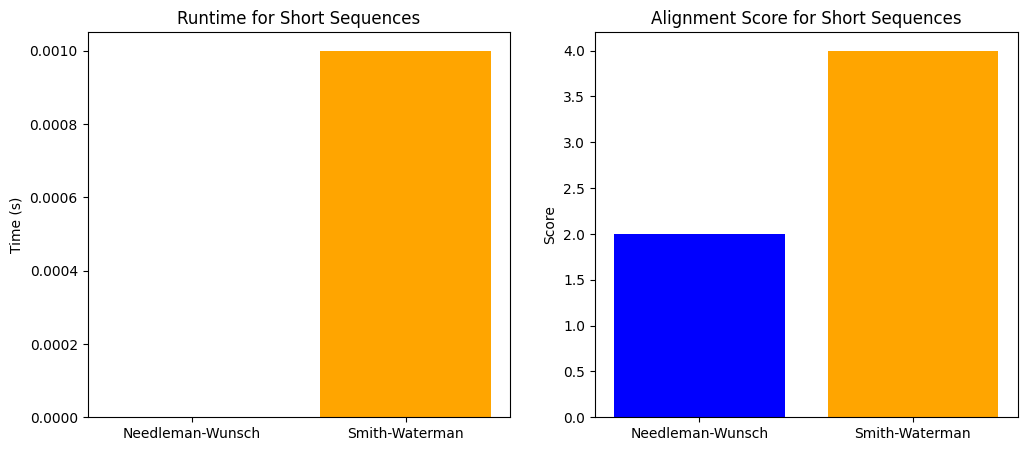


--- Test 2: Long Sequences with Local Similarity ---
Needleman-Wunsch Time: 0.002000s, Score: 20
Needleman-Wunsch Alignment (partial):
CT-CCCG-GGTTTACGTACGTACGTGTGCGACT-
ATGACTGTAGCGTTCGTACGTACGT-T-C-ATTG

Smith-Waterman Time: 0.002000s, Score: 27
Smith-Waterman Alignment:
CTCCCGGGTTTACGTACGTACGTGTGCGACT
CTGTAGCG-TT-CGTACGTACGT-T-C-ATT



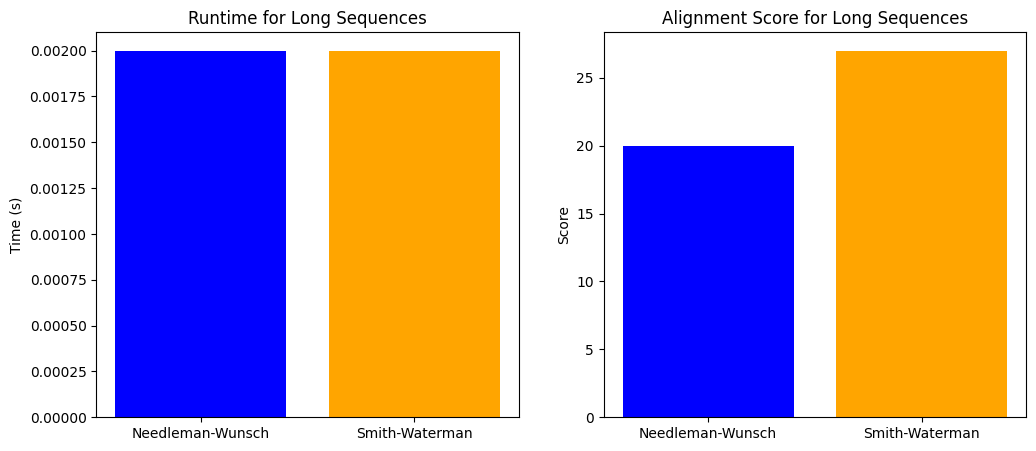

In [5]:
# --- Test 1: Short, Similar Sequences ---
print("--- Test 1: Short, Similar Sequences ---")
times, scores = [], []

start_time = time.time()
score_nw, aligned_nw1, aligned_nw2 = needleman_wunsch(seq_s1, seq_s2)
times.append(time.time() - start_time)
scores.append(score_nw)

start_time = time.time()
score_sw, aligned_sw1, aligned_sw2 = smith_waterman(seq_s1, seq_s2)
times.append(time.time() - start_time)
scores.append(score_sw)

print(f"Needleman-Wunsch Time: {times[0]:.6f}s, Score: {scores[0]}")
print(f"Needleman-Wunsch Alignment:\n{aligned_nw1}\n{aligned_nw2}\n")
print(f"Smith-Waterman Time: {times[1]:.6f}s, Score: {scores[1]}")
print(f"Smith-Waterman Alignment:\n{aligned_sw1}\n{aligned_sw2}\n")

algorithms = ['Needleman-Wunsch', 'Smith-Waterman']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(algorithms, times, color=['blue', 'orange'])
ax1.set_title('Runtime for Short Sequences')
ax1.set_ylabel('Time (s)')
ax2.bar(algorithms, scores, color=['blue', 'orange'])
ax2.set_title('Alignment Score for Short Sequences')
ax2.set_ylabel('Score')
plt.show()

# --- Test 2: Long Sequences with Local Similarity ---
print("\n--- Test 2: Long Sequences with Local Similarity ---")
start_time = time.time()
score_nw_l, aligned_nw_l1, aligned_nw_l2 = needleman_wunsch(seq_l1, seq_l2)
time_nw_l = time.time() - start_time

start_time = time.time()
score_sw_l, aligned_sw_l1, aligned_sw_l2 = smith_waterman(seq_l1, seq_l2)
time_sw_l = time.time() - start_time

print(f"Needleman-Wunsch Time: {time_nw_l:.6f}s, Score: {score_nw_l}")
print(f"Needleman-Wunsch Alignment (partial):\n{aligned_nw_l1[:50]}\n{aligned_nw_l2[:50]}\n")
print(f"Smith-Waterman Time: {time_sw_l:.6f}s, Score: {score_sw_l}")
print(f"Smith-Waterman Alignment:\n{aligned_sw_l1}\n{aligned_sw_l2}\n")

times_long = [time_nw_l, time_sw_l]
algorithms_long = ['Needleman-Wunsch', 'Smith-Waterman']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(algorithms_long, times_long, color=['blue', 'orange'])
ax1.set_title('Runtime for Long Sequences')
ax1.set_ylabel('Time (s)')
ax2.bar(algorithms_long, [score_nw_l, score_sw_l], color=['blue', 'orange'])
ax2.set_title('Alignment Score for Long Sequences')
ax2.set_ylabel('Score')
plt.show()